<a href="https://colab.research.google.com/github/DeepanshuSharma1607/Fake_News_Generator_in_python/blob/main/ipl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [352]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [353]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "IPL_ball_by_ball_updated.csv"

# Load the latest version
df_23= kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "dgsports/ipl-ball-by-ball-2008-to-2022",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

Using Colab cache for faster access to the 'ipl-ball-by-ball-2008-to-2022' dataset.


In [354]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "deliveries_updated_ipl_upto_2025.csv"

# Load the latest version
df_ = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "dgsports/ipl-ball-by-ball-2008-to-2022",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

Using Colab cache for faster access to the 'ipl-ball-by-ball-2008-to-2022' dataset.


In [355]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path1 = "ipl_2024_deliveries.csv"
file_path2 = "ipl_2025_deliveries.csv"
file_path3 = "ipl_2026_deliveries.csv"
# Load the latest version
df_24= kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "sahiltailor/ipl-2024-ball-by-ball-dataset",
  file_path1,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
df_25= kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "sahiltailor/ipl-2024-ball-by-ball-dataset",
  file_path2,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
df_26= kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "sahiltailor/ipl-2024-ball-by-ball-dataset",
  file_path3,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)



Using Colab cache for faster access to the 'ipl-2024-ball-by-ball-dataset' dataset.
Using Colab cache for faster access to the 'ipl-2024-ball-by-ball-dataset' dataset.
Using Colab cache for faster access to the 'ipl-2024-ball-by-ball-dataset' dataset.


In [356]:
df_['season']=pd.to_datetime(df_['date']).dt.year

In [357]:
dv=[df_,df_23,df_24,df_25,df_26]
mapping = {
    'start_date':'date'
}
df_23.rename(columns=mapping, inplace=True)

In [358]:
for df in dv:
  df['date']=pd.to_datetime(df['date'])

In [359]:
team_mapping = {
    # Current name
    'Delhi Capitals': 'DC',
    # Old name → same short code
    'Delhi Daredevils': 'DC',

    'Punjab Kings': 'PBKS',
    'Kings XI Punjab': 'PBKS',

    'Royal Challengers Bangalore': 'RCB',
    'Royal Challengers Bengaluru': 'RCB',

    # Never changed
    'Kolkata Knight Riders': 'KKR',
    'Chennai Super Kings': 'CSK',
    'Rajasthan Royals': 'RR',
    'Mumbai Indians': 'MI',
    'Sunrisers Hyderabad': 'SRH',
    'Lucknow Super Giants': 'LSG',
    'Gujarat Titans': 'GT',

    # Dissolved teams
    'Deccan Chargers': 'DC_OLD',
    'Kochi Tuskers Kerala': 'KTK',
    'Pune Warriors': 'PWI',
    'Rising Pune Supergiants': 'RPS',
    'Rising Pune Supergiant': 'RPS',
    'Gujarat Lions': 'GL',
}


# Apply to both team columns
df_['batting_team'] = df_['batting_team'].replace(team_mapping)
df_['bowling_team'] = df_['bowling_team'].replace(team_mapping)

df_23['batting_team'] = df_23['batting_team'].replace(team_mapping)
df_23['bowling_team'] = df_23['bowling_team'].replace(team_mapping)


In [360]:
venue_sources = [df_23, df_24, df_25, df_26]

venue_lookup = pd.concat([
    df[['date', 'batting_team', 'bowling_team', 'venue']]
    for df in venue_sources
]).drop_duplicates(subset=['date', 'batting_team', 'bowling_team'])

In [361]:
if 'venue' in df_.columns:
    df_ = df_.drop(columns=['venue'])

df_ = df_.merge(
    venue_lookup,
    on=['date', 'batting_team', 'bowling_team'],
    how='left'
)

In [362]:
df_.head(2)

,matchId,inning,over_ball,over,ball,batting_team,bowling_team,batsman,non_striker,bowler,...,isWide,isNoBall,Byes,LegByes,Penalty,dismissal_kind,player_dismissed,date,season,venue
0,335982,1,0.1,0,1,KKR,RCB,SC Ganguly,BB McCullum,P Kumar,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,2008-04-18,2008,M Chinnaswamy Stadium
1,335982,1,0.2,0,2,KKR,RCB,BB McCullum,SC Ganguly,P Kumar,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-18,2008,M Chinnaswamy Stadium


In [363]:
df_=df_.drop(columns=["over","ball"])

In [364]:
df_=df_.drop(columns=["date","Penalty"])

In [365]:
df_26=df_26.drop(columns=["date",'match_no',"phase"])

In [366]:
print(df_.shape)
print(df_26.shape)

(278205, 18)
(1382, 18)


In [367]:
df_.columns

Index(['matchId', 'inning', 'over_ball', 'batting_team', 'bowling_team',
       'batsman', 'non_striker', 'bowler', 'batsman_runs', 'extras', 'isWide',
       'isNoBall', 'Byes', 'LegByes', 'dismissal_kind', 'player_dismissed',
       'season', 'venue'],
      dtype='object')

In [368]:
mapping = {
    "innings":"inning",
    "fielder":"non_striker"

}
df_26.rename(columns=mapping, inplace=True)
df_26.columns

Index(['match_id', 'season', 'venue', 'batting_team', 'bowling_team', 'inning',
       'over', 'striker', 'bowler', 'runs_of_bat', 'extras', 'wide', 'legbyes',
       'byes', 'noballs', 'wicket_type', 'player_dismissed', 'non_striker'],
      dtype='object')

In [369]:
#Rename columns
mapping = {
    'matchId':'match_id',
    'over_ball':'over',
    'batsman':'striker',
    'isWide':'wide',
    'isNoBall':'noballs',
    "batsman_runs":"runs_of_bat",
    "dismissal_kind":"wicket_type",
    "LegByes":"legbyes",
    "Byes":"byes"

}
df_.rename(columns=mapping, inplace=True)

In [370]:
df_['venue'] = (df_['venue']
             .str.split(',').str[0]
             .str.strip()
             .str.lower()
             .str.replace(' ', '_'))


In [371]:
df = pd.concat([df_, df_26])
print(df.shape)
display(df.head())

(279587, 18)


,match_id,inning,over,batting_team,bowling_team,striker,non_striker,bowler,runs_of_bat,extras,wide,noballs,byes,legbyes,wicket_type,player_dismissed,season,venue
0,335982,1,0.1,KKR,RCB,SC Ganguly,BB McCullum,P Kumar,0,1,NaN,NaN,NaN,1.0,NaN,NaN,2008,m_chinnaswamy_stadium
1,335982,1,0.2,KKR,RCB,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2008,m_chinnaswamy_stadium
2,335982,1,0.3,KKR,RCB,BB McCullum,SC Ganguly,P Kumar,0,1,1.0,NaN,NaN,NaN,NaN,NaN,2008,m_chinnaswamy_stadium
3,335982,1,0.4,KKR,RCB,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2008,m_chinnaswamy_stadium
4,335982,1,0.5,KKR,RCB,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2008,m_chinnaswamy_stadium


In [372]:
df.isnull().sum()

,0
match_id,0
inning,0
over,0
batting_team,0
bowling_team,0
striker,0
non_striker,1319
bowler,0
runs_of_bat,0
extras,0


In [373]:
df['bowling_team'].nunique()

15

In [374]:
df.columns

Index(['match_id', 'inning', 'over', 'batting_team', 'bowling_team', 'striker',
       'non_striker', 'bowler', 'runs_of_bat', 'extras', 'wide', 'noballs',
       'byes', 'legbyes', 'wicket_type', 'player_dismissed', 'season',
       'venue'],
      dtype='object')

In [375]:
print(df[['runs_of_bat', 'extras', 'wide',
       'noballs', 'byes', 'legbyes', 'wicket_type', 'player_dismissed']])

      runs_of_bat  extras  wide  noballs  byes  legbyes wicket_type  \
0               0       1   NaN      NaN   NaN      1.0         NaN   
1               0       0   NaN      NaN   NaN      NaN         NaN   
2               0       1   1.0      NaN   NaN      NaN         NaN   
3               0       0   NaN      NaN   NaN      NaN         NaN   
4               0       0   NaN      NaN   NaN      NaN         NaN   
...           ...     ...   ...      ...   ...      ...         ...   
1377            1       0   0.0      0.0   0.0      0.0         NaN   
1378            0       0   0.0      0.0   0.0      0.0         NaN   
1379            1       0   0.0      0.0   0.0      0.0         NaN   
1380            0       0   0.0      0.0   0.0      0.0      caught   
1381            0       0   0.0      0.0   0.0      0.0      bowled   

         player_dismissed  
0                     NaN  
1                     NaN  
2                     NaN  
3                     NaN  
4      

In [376]:
cols_to_fix = ['runs_of_bat', 'extras', 'wide', 'noballs', 'byes', 'legbyes']
df[cols_to_fix] = df[cols_to_fix].fillna(0)

df['curr_ball_runs'] = df['runs_of_bat'] + df['extras']
total_score = df.groupby(['match_id', 'inning', 'batting_team'])['curr_ball_runs'].cumsum().reset_index()


In [377]:
df['team_runs'] = df.groupby(['match_id','batting_team'])['curr_ball_runs'].cumsum()
df['team_runs'] = df.groupby(['match_id','batting_team'])['team_runs'].shift(1).fillna(0)

In [378]:
df['first_innings_runs'] = np.where(df['inning'] == 1, df['team_runs'], 0)

df['second_innings_runs'] = np.where(df['inning'] == 2, df['team_runs'], 0)

In [379]:
df

,match_id,inning,over,batting_team,bowling_team,striker,non_striker,bowler,runs_of_bat,extras,...,byes,legbyes,wicket_type,player_dismissed,season,venue,curr_ball_runs,team_runs,first_innings_runs,second_innings_runs
0,335982,1,0.1,KKR,RCB,SC Ganguly,BB McCullum,P Kumar,0,1,...,0.0,1.0,NaN,NaN,2008,m_chinnaswamy_stadium,1,0.0,0.0,0.0
1,335982,1,0.2,KKR,RCB,BB McCullum,SC Ganguly,P Kumar,0,0,...,0.0,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,1.0,1.0,0.0
2,335982,1,0.3,KKR,RCB,BB McCullum,SC Ganguly,P Kumar,0,1,...,0.0,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,1,1.0,1.0,0.0
3,335982,1,0.4,KKR,RCB,BB McCullum,SC Ganguly,P Kumar,0,0,...,0.0,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,2.0,2.0,0.0
4,335982,1,0.5,KKR,RCB,BB McCullum,SC Ganguly,P Kumar,0,0,...,0.0,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,2.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1377,202606,2,15.2,KKR,SRH,Kartik Tyagi,NaN,Jaydev Unadkat,1,0,...,0.0,0.0,NaN,NaN,2026,"Eden Gardens, Kolkata",1,158.0,0.0,158.0
1378,202606,2,15.3,KKR,SRH,Vaibhav Arora,NaN,Jaydev Unadkat,0,0,...,0.0,0.0,NaN,NaN,2026,"Eden Gardens, Kolkata",0,159.0,0.0,159.0
1379,202606,2,15.4,KKR,SRH,Vaibhav Arora,NaN,Jaydev Unadkat,1,0,...,0.0,0.0,NaN,NaN,2026,"Eden Gardens, Kolkata",1,159.0,0.0,159.0
1380,202606,2,15.5,KKR,SRH,Kartik Tyagi,Ishan Kishan,Jaydev Unadkat,0,0,...,0.0,0.0,caught,Kartik Tyagi,2026,"Eden Gardens, Kolkata",0,160.0,0.0,160.0


In [380]:
df['is_wicket']=df['player_dismissed'].notna().astype(int)

In [381]:
df.columns

Index(['match_id', 'inning', 'over', 'batting_team', 'bowling_team', 'striker',
       'non_striker', 'bowler', 'runs_of_bat', 'extras', 'wide', 'noballs',
       'byes', 'legbyes', 'wicket_type', 'player_dismissed', 'season', 'venue',
       'curr_ball_runs', 'team_runs', 'first_innings_runs',
       'second_innings_runs', 'is_wicket'],
      dtype='object')

In [382]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 279587 entries, 0 to 1381
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   match_id             279587 non-null  int64  
 1   inning               279587 non-null  int64  
 2   over                 279587 non-null  float64
 3   batting_team         279587 non-null  object 
 4   bowling_team         279587 non-null  object 
 5   striker              279587 non-null  object 
 6   non_striker          278268 non-null  object 
 7   bowler               279587 non-null  object 
 8   runs_of_bat          279587 non-null  int64  
 9   extras               279587 non-null  int64  
 10  wide                 279587 non-null  float64
 11  noballs              279587 non-null  float64
 12  byes                 279587 non-null  float64
 13  legbyes              279587 non-null  float64
 14  wicket_type          13904 non-null   object 
 15  player_dismissed     139

In [383]:
df

,match_id,inning,over,batting_team,bowling_team,striker,non_striker,bowler,runs_of_bat,extras,...,legbyes,wicket_type,player_dismissed,season,venue,curr_ball_runs,team_runs,first_innings_runs,second_innings_runs,is_wicket
0,335982,1,0.1,KKR,RCB,SC Ganguly,BB McCullum,P Kumar,0,1,...,1.0,NaN,NaN,2008,m_chinnaswamy_stadium,1,0.0,0.0,0.0,0
1,335982,1,0.2,KKR,RCB,BB McCullum,SC Ganguly,P Kumar,0,0,...,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,1.0,1.0,0.0,0
2,335982,1,0.3,KKR,RCB,BB McCullum,SC Ganguly,P Kumar,0,1,...,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,1,1.0,1.0,0.0,0
3,335982,1,0.4,KKR,RCB,BB McCullum,SC Ganguly,P Kumar,0,0,...,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,2.0,2.0,0.0,0
4,335982,1,0.5,KKR,RCB,BB McCullum,SC Ganguly,P Kumar,0,0,...,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,2.0,2.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1377,202606,2,15.2,KKR,SRH,Kartik Tyagi,NaN,Jaydev Unadkat,1,0,...,0.0,NaN,NaN,2026,"Eden Gardens, Kolkata",1,158.0,0.0,158.0,0
1378,202606,2,15.3,KKR,SRH,Vaibhav Arora,NaN,Jaydev Unadkat,0,0,...,0.0,NaN,NaN,2026,"Eden Gardens, Kolkata",0,159.0,0.0,159.0,0
1379,202606,2,15.4,KKR,SRH,Vaibhav Arora,NaN,Jaydev Unadkat,1,0,...,0.0,NaN,NaN,2026,"Eden Gardens, Kolkata",1,159.0,0.0,159.0,0
1380,202606,2,15.5,KKR,SRH,Kartik Tyagi,Ishan Kishan,Jaydev Unadkat,0,0,...,0.0,caught,Kartik Tyagi,2026,"Eden Gardens, Kolkata",0,160.0,0.0,160.0,1


In [384]:
final_scores = df[df['inning'] == 1].groupby('match_id')['team_runs'].max()
df = df.merge(final_scores.rename('target'), on='match_id')
df['target'] = np.where(df['inning'] == 2, df['target'] + 1, 0)

In [385]:
df['over_'] = df['over'].astype(str).str.split('.').str[0].astype(int)
df['ball_in_over'] = (df['over'].astype(str)
                      .str.split('.')
                      .str[1]
                      .fillna(0)
                      .astype(int))

In [386]:
df['ball_in_over'] = df['ball_in_over'].clip(upper=6)
df['balls_bowled'] = df['over_'] * 6 + df['ball_in_over']

In [387]:
df['runs_to_win'] = np.where(
    df['inning'] == 2,
    df['target'] - df['team_runs'],
    0
)

In [388]:
balls_remaining = (120 - df['balls_bowled']).clip(lower=0)


In [389]:
df['curr_run_rate'] = np.where(
    df['balls_bowled'] == 0, 0,
    (df['team_runs'] * 6) / df['balls_bowled']
)

In [390]:
df['req_run_rate'] = np.where(
    balls_remaining == 0,
    np.inf,
    (df['runs_to_win'] * 6) / balls_remaining
)
df['req_run_rate'] = df['req_run_rate'].clip(0, 36)


In [391]:
df['req_run_rate'] = df['req_run_rate'].replace(np.inf, 100)

In [392]:
df['crr_rrr_ratio'] = df['curr_run_rate'] / df['req_run_rate'].replace(0, np.inf)

df['crr_rrr_ratio'] = df['crr_rrr_ratio'].clip(0, 10)

df.loc[df['inning'] == 1,
       ['target', 'runs_to_win', 'req_run_rate', 'crr_rrr_ratio']] = 0

In [393]:
df['balls_remaining'] = (20 * 6) - df['balls_bowled']

In [394]:
df['total_wickets'] = df.groupby(['match_id','inning'])['is_wicket'].cumsum()
df['total_wickets'] = df.groupby(['match_id','inning'])['total_wickets'].shift(1).fillna(0)
df['wickets_remaining'] = 10 - df['total_wickets']

In [395]:
df

,match_id,inning,over,batting_team,bowling_team,striker,non_striker,bowler,runs_of_bat,extras,...,over_,ball_in_over,balls_bowled,runs_to_win,curr_run_rate,req_run_rate,crr_rrr_ratio,balls_remaining,total_wickets,wickets_remaining
0,335982,1,0.1,KKR,RCB,SC Ganguly,BB McCullum,P Kumar,0,1,...,0,1,1,0.0,0.000000,0.000000,0.000000,119,0.0,10.0
1,335982,1,0.2,KKR,RCB,BB McCullum,SC Ganguly,P Kumar,0,0,...,0,2,2,0.0,3.000000,0.000000,0.000000,118,0.0,10.0
2,335982,1,0.3,KKR,RCB,BB McCullum,SC Ganguly,P Kumar,0,1,...,0,3,3,0.0,2.000000,0.000000,0.000000,117,0.0,10.0
3,335982,1,0.4,KKR,RCB,BB McCullum,SC Ganguly,P Kumar,0,0,...,0,4,4,0.0,3.000000,0.000000,0.000000,116,0.0,10.0
4,335982,1,0.5,KKR,RCB,BB McCullum,SC Ganguly,P Kumar,0,0,...,0,5,5,0.0,2.400000,0.000000,0.000000,115,0.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279582,202606,2,15.2,KKR,SRH,Kartik Tyagi,NaN,Jaydev Unadkat,1,0,...,15,2,92,69.0,10.304348,14.785714,0.696912,28,8.0,2.0
279583,202606,2,15.3,KKR,SRH,Vaibhav Arora,NaN,Jaydev Unadkat,0,0,...,15,3,93,68.0,10.258065,15.111111,0.678843,27,8.0,2.0
279584,202606,2,15.4,KKR,SRH,Vaibhav Arora,NaN,Jaydev Unadkat,1,0,...,15,4,94,68.0,10.148936,15.692308,0.646746,26,8.0,2.0
279585,202606,2,15.5,KKR,SRH,Kartik Tyagi,Ishan Kishan,Jaydev Unadkat,0,0,...,15,5,95,67.0,10.105263,16.080000,0.628437,25,8.0,2.0


In [396]:
df.columns

Index(['match_id', 'inning', 'over', 'batting_team', 'bowling_team', 'striker',
       'non_striker', 'bowler', 'runs_of_bat', 'extras', 'wide', 'noballs',
       'byes', 'legbyes', 'wicket_type', 'player_dismissed', 'season', 'venue',
       'curr_ball_runs', 'team_runs', 'first_innings_runs',
       'second_innings_runs', 'is_wicket', 'target', 'over_', 'ball_in_over',
       'balls_bowled', 'runs_to_win', 'curr_run_rate', 'req_run_rate',
       'crr_rrr_ratio', 'balls_remaining', 'total_wickets',
       'wickets_remaining'],
      dtype='object')

In [397]:
df['is_out'] = (df['player_dismissed'] == df['striker']).astype(int)

df['valid_ball'] = (df['wide'] == 0).astype(int)

# df['batsman_run_cum'] = df.groupby(['match_id','striker'])['runs_off_bat'].cumsum()
# df['batsman_run_cum'] = df.groupby(['match_id','striker'])['batsman_run_cum'].shift(1).fillna(0)

# df['balls_faced_cum'] = df.groupby(['match_id','striker'])['valid_ball'].cumsum()
# df['balls_faced_cum'] = df.groupby(['match_id','striker'])['balls_faced_cum'].shift(1).fillna(0)

# df['match_strike_rate'] = np.where(
#     df['balls_faced_cum'] == 0,
#     0,
#     (df['batsman_run_cum'] / df['balls_faced_cum']) * 100
# )



# df['batsman_run_cum_career'] = df.groupby('striker')['runs_off_bat'].cumsum()
# df['batsman_run_cum_career'] = df.groupby('striker')['batsman_run_cum_career'].shift(1).fillna(0)

# df['balls_faced_cum_career'] = df.groupby('striker')['valid_ball'].cumsum()
# df['balls_faced_cum_career'] = df.groupby('striker')['balls_faced_cum_career'].shift(1).fillna(0)

# df['batsman_outs_career'] = df.groupby('striker')['is_out'].cumsum()
# df['batsman_outs_career'] = df.groupby('striker')['batsman_outs_career'].shift(1).fillna(0)

# universal_runs = 50
# universal_outs = 2

# df['batting_average'] = (
#     df['batsman_run_cum_career'] + universal_runs
# ) / (
#     df['batsman_outs_career'] + universal_outs
# )


# universal_sr_runs = 100
# universal_balls = 80

# df['career_strike_rate'] = (
#     (df['batsman_run_cum_career'] + universal_sr_runs) /
#     (df['balls_faced_cum_career'] + universal_balls)
# ) * 100
# Aggregate per striker per season
season_bat = df.groupby(['season', 'striker']).agg(
    season_runs=('runs_of_bat', 'sum'),
    season_balls=('valid_ball', 'sum'),
    season_outs=('is_out', 'sum')
).reset_index().sort_values(['striker', 'season'])

# Cumsum then shift — so current season stats NOT included
season_bat['career_runs'] = season_bat.groupby('striker')['season_runs'].cumsum().shift(1).fillna(0)
season_bat['career_balls'] = season_bat.groupby('striker')['season_balls'].cumsum().shift(1).fillna(0)
season_bat['career_outs'] = season_bat.groupby('striker')['season_outs'].cumsum().shift(1).fillna(0)

# Smoothed stats
season_bat['batting_average'] = (season_bat['career_runs'] + 50) / (season_bat['career_outs'] + 2)
season_bat['career_strike_rate'] = ((season_bat['career_runs'] + 100) / (season_bat['career_balls'] + 80)) * 100

# Merge back
df = df.merge(
    season_bat[['season', 'striker', 'batting_average', 'career_strike_rate']],
    on=['season', 'striker'], how='left'
)

In [398]:


# df['bowler_runs_conceded'] = df.groupby('bowler')['runs_off_bat'].cumsum()
# df['bowler_runs_conceded'] = df.groupby('bowler')['bowler_runs_conceded'].shift(1).fillna(0)

# df['bowler_balls_bowled'] = df.groupby('bowler')['valid_ball'].cumsum()
# df['bowler_balls_bowled'] = df.groupby('bowler')['bowler_balls_bowled'].shift(1).fillna(0)

# df['bowler_wickets_cum'] = df.groupby('bowler')['is_wicket'].cumsum()
# df['bowler_wickets_cum'] = df.groupby('bowler')['bowler_wickets_cum'].shift(1).fillna(0)



# universal_runs_conceded = 300
# universal_balls = 240
# universal_wickets = 10


# df['exp_bowler_eco'] = (
#     (df['bowler_runs_conceded'] + universal_runs_conceded) /
#     (df['bowler_balls_bowled'] + universal_balls)
# ) * 6


# df['exp_bowler_avg'] = (
#     df['bowler_runs_conceded'] + universal_runs_conceded
# ) / (
#     df['bowler_wickets_cum'] + universal_wickets
# )
# Aggregate per bowler per season
season_bowl = df.groupby(['season', 'bowler']).agg(
    season_runs_c=('runs_of_bat', 'sum'),
    season_balls_b=('valid_ball', 'sum'),
    season_wkts=('is_wicket', 'sum')
).reset_index().sort_values(['bowler', 'season'])

# Cumsum then shift — so current season NOT included
season_bowl['career_runs_c'] = season_bowl.groupby('bowler')['season_runs_c'].cumsum().shift(1).fillna(0)
season_bowl['career_balls_b'] = season_bowl.groupby('bowler')['season_balls_b'].cumsum().shift(1).fillna(0)
season_bowl['career_wkts'] = season_bowl.groupby('bowler')['season_wkts'].cumsum().shift(1).fillna(0)

# Smoothed stats
season_bowl['exp_bowler_eco'] = ((season_bowl['career_runs_c'] + 300) / (season_bowl['career_balls_b'] + 240)) * 6
season_bowl['exp_bowler_avg'] = (season_bowl['career_runs_c'] + 300) / (season_bowl['career_wkts'] + 10)

# Merge back
df = df.merge(
    season_bowl[['season', 'bowler', 'exp_bowler_eco', 'exp_bowler_avg']],
    on=['season', 'bowler'], how='left'
)

In [399]:
df.columns

Index(['match_id', 'inning', 'over', 'batting_team', 'bowling_team', 'striker',
       'non_striker', 'bowler', 'runs_of_bat', 'extras', 'wide', 'noballs',
       'byes', 'legbyes', 'wicket_type', 'player_dismissed', 'season', 'venue',
       'curr_ball_runs', 'team_runs', 'first_innings_runs',
       'second_innings_runs', 'is_wicket', 'target', 'over_', 'ball_in_over',
       'balls_bowled', 'runs_to_win', 'curr_run_rate', 'req_run_rate',
       'crr_rrr_ratio', 'balls_remaining', 'total_wickets',
       'wickets_remaining', 'is_out', 'valid_ball', 'batting_average',
       'career_strike_rate', 'exp_bowler_eco', 'exp_bowler_avg'],
      dtype='object')

In [400]:
df.shape

(279587, 40)

In [401]:
final_scores = df.groupby(['match_id', 'inning'])['team_runs'].max().reset_index()
final_scores = final_scores.pivot(index='match_id', columns='inning', values='team_runs').reset_index()
final_scores['winner_innings'] = np.where(
    final_scores[2] > final_scores[1], 2,
    np.where(final_scores[2] < final_scores[1], 1, 0)
)

df = df.merge(final_scores[['match_id', 'winner_innings']], on='match_id', how='left')

df['result'] = np.where(
    (df['inning'] == 2) & (df['winner_innings'] == 2),
    1,
    np.where(
        (df['inning'] == 2) & (df['winner_innings'] == 1),
        0,
        -1   # tie
    )
)

In [402]:
df['match_phase'] = pd.cut(df['over_'],
                            bins=[-1, 5, 14, 19],
                            labels=[0, 1, 2]).astype(int)

In [403]:
df['first_innings_total'] = df['target'] - 1

In [404]:
df.shape

(279587, 44)

In [405]:
df.columns

Index(['match_id', 'inning', 'over', 'batting_team', 'bowling_team', 'striker',
       'non_striker', 'bowler', 'runs_of_bat', 'extras', 'wide', 'noballs',
       'byes', 'legbyes', 'wicket_type', 'player_dismissed', 'season', 'venue',
       'curr_ball_runs', 'team_runs', 'first_innings_runs',
       'second_innings_runs', 'is_wicket', 'target', 'over_', 'ball_in_over',
       'balls_bowled', 'runs_to_win', 'curr_run_rate', 'req_run_rate',
       'crr_rrr_ratio', 'balls_remaining', 'total_wickets',
       'wickets_remaining', 'is_out', 'valid_ball', 'batting_average',
       'career_strike_rate', 'exp_bowler_eco', 'exp_bowler_avg',
       'winner_innings', 'result', 'match_phase', 'first_innings_total'],
      dtype='object')

In [406]:
drop_list = ['match_id',
     'runs_of_bat', 'extras', 'wide',
    'noballs', 'byes', 'legbyes',  'curr_ball_runs',
    'wicket_type', 'player_dismissed',  'is_wicket', 'is_out', 'winner_innings',
    'over', 'over_', 'ball_in_over', 'balls_bowled', 'valid_ball',
    'team_runs', 'first_innings_runs', 'second_innings_runs', 'target',
    # 'batsman_run_cum', 'balls_faced_cum',
    'total_wickets'
]
df = df.drop(columns=drop_list)

In [407]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279587 entries, 0 to 279586
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   inning               279587 non-null  int64  
 1   batting_team         279587 non-null  object 
 2   bowling_team         279587 non-null  object 
 3   striker              279587 non-null  object 
 4   non_striker          278268 non-null  object 
 5   bowler               279587 non-null  object 
 6   season               279587 non-null  int64  
 7   venue                279587 non-null  object 
 8   runs_to_win          279587 non-null  float64
 9   curr_run_rate        279587 non-null  float64
 10  req_run_rate         279587 non-null  float64
 11  crr_rrr_ratio        279587 non-null  float64
 12  balls_remaining      279587 non-null  int64  
 13  wickets_remaining    279587 non-null  float64
 14  batting_average      279587 non-null  float64
 15  career_strike_rat

In [408]:
df['pressure'] = df['req_run_rate'] - df['curr_run_rate']

In [409]:
df = df[df['inning'] <= 2]
df = df[df['result'] != -1]


In [410]:
df.describe()

,inning,season,runs_to_win,curr_run_rate,req_run_rate,crr_rrr_ratio,balls_remaining,wickets_remaining,batting_average,career_strike_rate,exp_bowler_eco,exp_bowler_avg,result,match_phase,first_innings_total,pressure
count,118948.0,118948.000000,118948.000000,118948.000000,118948.000000,118948.000000,118948.000000,118948.000000,118948.000000,118948.000000,118948.000000,118948.000000,118948.000000,118948.000000,118948.000000,118948.000000
mean,2.0,2016.805007,96.427279,7.365233,10.497059,0.916987,62.673034,7.487658,27.990348,129.719408,7.576274,26.831533,0.274036,0.884782,169.634227,3.131826
std,0.0,5.260532,51.413062,2.365627,5.922369,0.904601,33.497982,2.178139,8.533226,12.829069,0.533086,4.950544,0.446029,0.719754,30.950901,6.366110
min,2.0,2008.000000,-15.000000,0.000000,0.000000,0.000000,0.000000,1.000000,5.428571,82.530120,5.914198,14.846154,0.000000,0.000000,61.000000,-17.582609
25%,2.0,2012.000000,56.000000,6.200000,7.520000,0.526119,34.000000,6.000000,22.363636,121.806167,7.266833,23.186047,0.000000,0.000000,149.000000,-0.401880
50%,2.0,2017.000000,95.000000,7.500000,9.263158,0.759870,63.000000,8.000000,28.000000,128.485964,7.601918,26.142857,0.000000,1.000000,169.000000,2.219843
75%,2.0,2022.000000,134.000000,8.777778,11.547170,1.042835,92.000000,9.000000,32.928571,136.785714,7.922099,30.090909,1.000000,1.000000,189.000000,5.306667
max,2.0,2026.000000,286.000000,24.000000,36.000000,10.000000,119.000000,10.000000,67.333333,194.570136,9.425287,45.312500,1.000000,2.000000,285.000000,31.565217


In [411]:
df = df[df['inning'] == 2]
df = df[df['runs_to_win'] >= 0]
df = df[df['balls_remaining'] > 0]

In [412]:
df.describe()

,inning,season,runs_to_win,curr_run_rate,req_run_rate,crr_rrr_ratio,balls_remaining,wickets_remaining,batting_average,career_strike_rate,exp_bowler_eco,exp_bowler_avg,result,match_phase,first_innings_total,pressure
count,118010.0,118010.000000,118010.000000,118010.000000,118010.000000,118010.000000,118010.000000,118010.000000,118010.000000,118010.000000,118010.000000,118010.000000,118010.000000,118010.000000,118010.000000,118010.000000
mean,2.0,2016.805398,97.101941,7.357271,10.405391,0.923187,63.131345,7.513270,28.024239,129.747427,7.575376,26.830011,0.272604,0.876299,169.628743,3.048120
std,0.0,5.261455,51.028299,2.370056,5.642818,0.905445,33.219315,2.158051,8.524040,12.818901,0.533402,4.951331,0.445301,0.716013,30.951359,6.114806
min,2.0,2008.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,5.428571,82.530120,5.914198,14.846154,0.000000,0.000000,61.000000,-17.582609
25%,2.0,2012.000000,57.000000,6.187500,7.529412,0.532174,35.000000,6.000000,22.465909,121.807229,7.266776,23.186047,0.000000,0.000000,149.000000,-0.391304
50%,2.0,2017.000000,96.000000,7.481481,9.257143,0.763636,64.000000,8.000000,28.026443,128.511967,7.601918,26.142857,0.000000,1.000000,169.000000,2.211429
75%,2.0,2022.000000,135.000000,8.769231,11.505882,1.045977,92.000000,9.000000,32.928571,136.785714,7.922099,30.090909,1.000000,1.000000,189.000000,5.257172
max,2.0,2026.000000,286.000000,24.000000,36.000000,10.000000,119.000000,10.000000,67.333333,194.570136,9.425287,45.312500,1.000000,2.000000,285.000000,31.565217


In [413]:
df = df.sort_values(['season'])
train_df = df[df['season'] <= 2024]
test_df  = df[df['season'] >= 2025]
x_train = train_df.drop(columns=['result', 'inning'])
y_train = train_df['result']
x_test = test_df.drop(columns=['result', 'inning'])
y_test = test_df['result']

In [414]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110151 entries, 143 to 243952
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   batting_team         110151 non-null  object 
 1   bowling_team         110151 non-null  object 
 2   striker              110151 non-null  object 
 3   non_striker          110151 non-null  object 
 4   bowler               110151 non-null  object 
 5   season               110151 non-null  int64  
 6   venue                110151 non-null  object 
 7   runs_to_win          110151 non-null  float64
 8   curr_run_rate        110151 non-null  float64
 9   req_run_rate         110151 non-null  float64
 10  crr_rrr_ratio        110151 non-null  float64
 11  balls_remaining      110151 non-null  int64  
 12  wickets_remaining    110151 non-null  float64
 13  batting_average      110151 non-null  float64
 14  career_strike_rate   110151 non-null  float64
 15  exp_bowler_eco      

In [415]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder,TargetEncoder,StandardScaler,OrdinalEncoder,RobustScaler
from sklearn.linear_model import LogisticRegression
nominal_cols=['batting_team','bowling_team']
categorical_cols=['venue','striker','bowler','non_striker']
numeric_cols=['runs_to_win',
              'curr_run_rate', 'req_run_rate',
              'crr_rrr_ratio',
              'balls_remaining', 'wickets_remaining', 'match_phase',
              'batting_average',
              'pressure',
              'career_strike_rate',
              'first_innings_total',
              'exp_bowler_eco', 'exp_bowler_avg','season']
print("Infinite values remaining:", np.isinf(df[numeric_cols]).values.sum())
preprocessing=ColumnTransformer(transformers=[
    ('nominal',OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'),nominal_cols),
    ('categorical',TargetEncoder(cv=5),categorical_cols),
    ('scalar',StandardScaler(),numeric_cols)
])


Infinite values remaining: 0


In [416]:
pipe=make_pipeline(preprocessing,LogisticRegression(C=0.001, solver='liblinear', max_iter=1000))

In [417]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np

cv_scores = []

seasons = sorted(train_df['season'].unique())

for i in range(5, len(seasons)):

    train_seasons = seasons[:i]
    val_season = seasons[i]

    train_fold = train_df[train_df['season'].isin(train_seasons)]
    val_fold   = train_df[train_df['season'] == val_season]

    X_tr = train_fold.drop(columns=['result', 'inning'])
    y_tr = train_fold['result']

    X_val = val_fold.drop(columns=['result', 'inning'])
    y_val = val_fold['result']

    pipe.fit(X_tr, y_tr)

    pred = pipe.predict(X_val)
    prob = pipe.predict_proba(X_val)[:,1]

    acc = accuracy_score(y_val, pred)
    f1  = f1_score(y_val, pred)
    auc = roc_auc_score(y_val, prob)

    print(f"{train_seasons[-1]} → {val_season} | Acc:{acc:.3f} F1:{f1:.3f} AUC:{auc:.3f}")

    cv_scores.append((acc, f1, auc))

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


2012 → 2013 | Acc:0.741 F1:0.208 AUC:0.748
2013 → 2014 | Acc:0.738 F1:0.301 AUC:0.763
2014 → 2015 | Acc:0.731 F1:0.281 AUC:0.795


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


2015 → 2016 | Acc:0.651 F1:0.318 AUC:0.747
2016 → 2017 | Acc:0.726 F1:0.339 AUC:0.671
2017 → 2018 | Acc:0.748 F1:0.257 AUC:0.722
2018 → 2019 | Acc:0.681 F1:0.441 AUC:0.820
2019 → 2020 | Acc:0.705 F1:0.377 AUC:0.735
2020 → 2021 | Acc:0.690 F1:0.453 AUC:0.743


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


2021 → 2022 | Acc:0.826 F1:0.409 AUC:0.826
2022 → 2023 | Acc:0.788 F1:0.333 AUC:0.755
2023 → 2024 | Acc:0.743 F1:0.309 AUC:0.741


In [418]:
pipe.fit(x_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('nominal',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['batting_team',
                                                   'bowling_team']),
                                                 ('categorical',
                                                  TargetEncoder(),
                                                  ['venue', 'striker', 'bowler',
                                                   'non_striker']),
                                                 ('scalar', StandardScaler(),
                                                  ['runs_to_win',
                                                   'curr_run_rate',
                                                   'req_run_rate',
                                                   'crr_rrr_ratio',
                                                   'balls_remaining',
                                                   'wickets_remaining',
                                                   'match_phase',
                                                   'batting_average',
                                                   'pressure',
                                                   'career_strike_rate',
                                                   'first_innings_total',
                                                   'exp_bowler_eco',
                                                   'exp_bowler_avg',
                                                   'season'])])),
                ('logisticregression',
                 LogisticRegression(C=0.001, max_iter=1000,
                                    solver='liblinear'))])

In [419]:
proba_train=pipe.predict(x_train)

In [420]:
proba_test=pipe.predict(x_test)

In [421]:
from sklearn.metrics import roc_auc_score,f1_score,accuracy_score
print(accuracy_score(proba_train,y_train))
print(accuracy_score(proba_test,y_test))

0.7682090947880637
0.7371166815116427


In [422]:
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder,TargetEncoder,StandardScaler

nominal_cols=['batting_team','bowling_team']
categorical_cols=['venue','striker','bowler','non_striker']
numeric_cols=['runs_to_win',
              'curr_run_rate', 'req_run_rate',
              'crr_rrr_ratio',
              'balls_remaining', 'wickets_remaining', 'match_phase',
              'batting_average',
              'pressure',
              'career_strike_rate',
              'first_innings_total','season',
              'exp_bowler_eco', 'exp_bowler_avg']

preprocessing_for_xgb = ColumnTransformer(transformers=[
    ('nominal', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), nominal_cols),
     ('scalar', StandardScaler(), numeric_cols),
    ('categorical',TargetEncoder(cv=5), categorical_cols)

])

xgb_pipe = make_pipeline(
    preprocessing_for_xgb,
    XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=5,
    reg_alpha=1,
    min_child_weight=10,
    gamma=1,
    eval_metric='logloss',
    random_state=69
)
)

xgb_pipe.fit(x_train, y_train)

print("Train:", accuracy_score(y_train, xgb_pipe.predict(x_train)))
print("Test: ", accuracy_score(y_test,  xgb_pipe.predict(x_test)))

Train: 0.8346724042450817
Test:  0.7098867540399542


In [424]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np

cv_scores_xgb = []

seasons = sorted(train_df['season'].unique())

for i in range(5, len(seasons)):

    train_seasons = seasons[:i]
    val_season = seasons[i]

    train_fold = train_df[train_df['season'].isin(train_seasons)]
    val_fold   = train_df[train_df['season'] == val_season]

    X_tr = train_fold.drop(columns=['result', 'inning'])
    y_tr = train_fold['result']

    X_val = val_fold.drop(columns=['result', 'inning'])
    y_val = val_fold['result']

    pipe.fit(X_tr, y_tr)

    pred_xgb = pipe.predict(X_val)
    prob_xgb = pipe.predict_proba(X_val)[:,1]

    acc_xgb = accuracy_score(y_val, pred_xgb)
    f1_xgb = f1_score(y_val, pred_xgb)
    auc_xgb = roc_auc_score(y_val, prob_xgb)

    print(f"{train_seasons[-1]} → {val_season} | Acc:{acc_xgb:.3f} F1:{f1_xgb:.3f} AUC:{auc_xgb:.3f}")

    cv_scores_xgb.append((acc_xgb, f1_xgb, auc_xgb))

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


2012 → 2013 | Acc:0.741 F1:0.208 AUC:0.748
2013 → 2014 | Acc:0.738 F1:0.301 AUC:0.763
2014 → 2015 | Acc:0.731 F1:0.281 AUC:0.795


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


2015 → 2016 | Acc:0.650 F1:0.317 AUC:0.747
2016 → 2017 | Acc:0.726 F1:0.339 AUC:0.671
2017 → 2018 | Acc:0.748 F1:0.256 AUC:0.722
2018 → 2019 | Acc:0.681 F1:0.441 AUC:0.820
2019 → 2020 | Acc:0.704 F1:0.377 AUC:0.735
2020 → 2021 | Acc:0.690 F1:0.453 AUC:0.743


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


2021 → 2022 | Acc:0.826 F1:0.409 AUC:0.826
2022 → 2023 | Acc:0.788 F1:0.334 AUC:0.755
2023 → 2024 | Acc:0.743 F1:0.309 AUC:0.741


In [425]:
prob_xgb = xgb_pipe.predict_proba(x_test)[:, 1]
prob_lr = pipe.predict_proba(x_test)[:, 1]

In [426]:
prob_ensemble = (0.65 * prob_xgb) + (0.35 * prob_lr)
pred_ensemble = (prob_ensemble >= 0.5).astype(int)
print("Weighted Ensemble:", accuracy_score(y_test, pred_ensemble))

Weighted Ensemble: 0.7293548797556941


In [427]:
x_train.columns

Index(['batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler',
       'season', 'venue', 'runs_to_win', 'curr_run_rate', 'req_run_rate',
       'crr_rrr_ratio', 'balls_remaining', 'wickets_remaining',
       'batting_average', 'career_strike_rate', 'exp_bowler_eco',
       'exp_bowler_avg', 'match_phase', 'first_innings_total', 'pressure'],
      dtype='object')


★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
   LOGISTIC REGRESSION
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

  LR — Train
  Accuracy  : 0.7647
  Precision : 0.6392
  Recall    : 0.3227
  F1 Score  : 0.4289
  ROC-AUC   : 0.8128
  Log Loss  : 0.4640
  Brier     : 0.1532

  Classification Report:
                   precision    recall  f1-score   support

Bowling Team Wins       0.78      0.93      0.85     79998
Batting Team Wins       0.64      0.32      0.43     30153

         accuracy                           0.76    110151
        macro avg       0.71      0.63      0.64    110151
     weighted avg       0.74      0.76      0.74    110151


  LR — Test
  Accuracy  : 0.7425
  Precision : 0.4962
  Recall    : 0.2246
  F1 Score  : 0.3092
  ROC-AUC   : 0.7242
  Log Loss  : 0.5054
  Brier     : 0.1690

  Classification Report:
                   precision    recall  f1-score   support

Bowling Team Wins       0.77      0.92      0.84      5842
Batting Team Wins       0.50      0

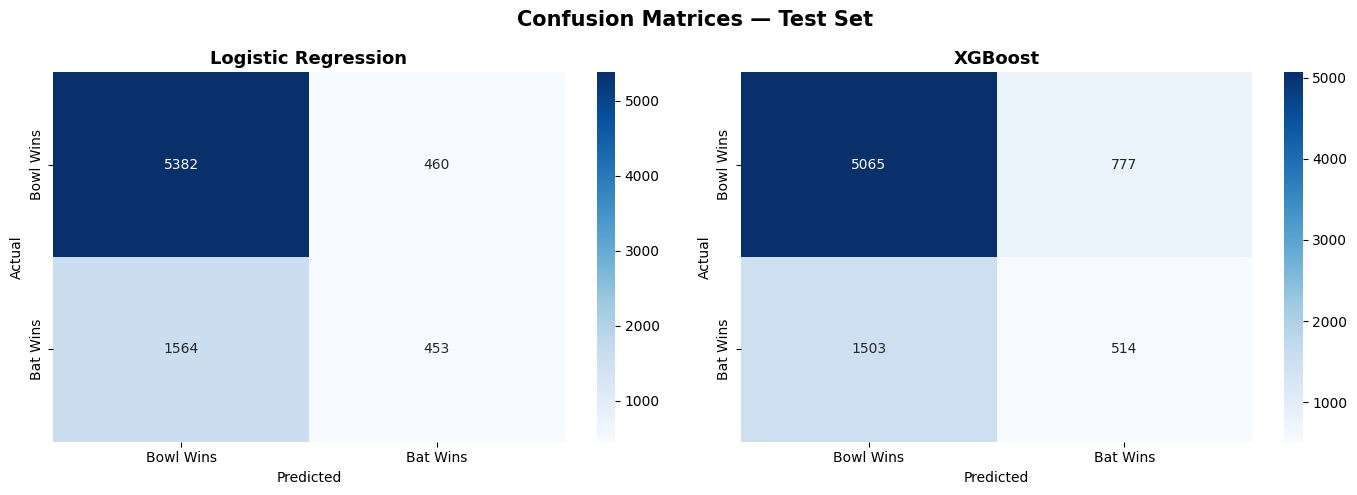

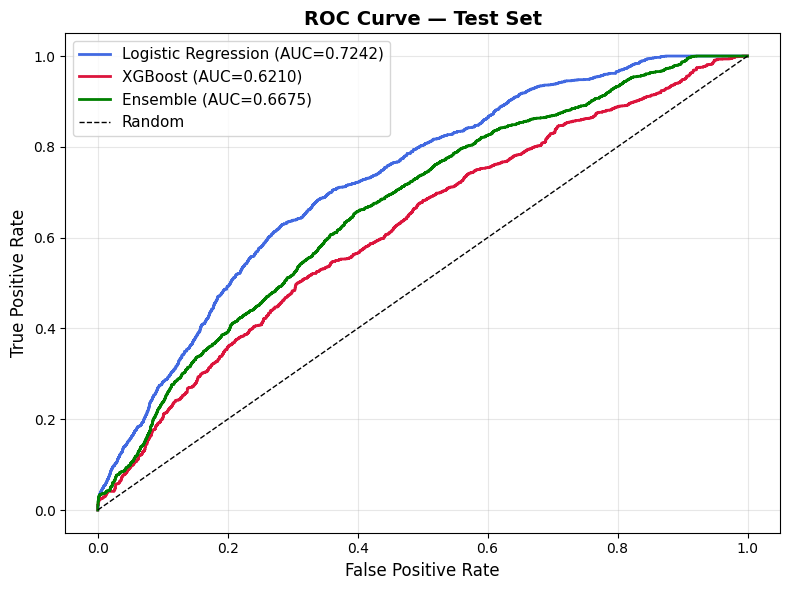

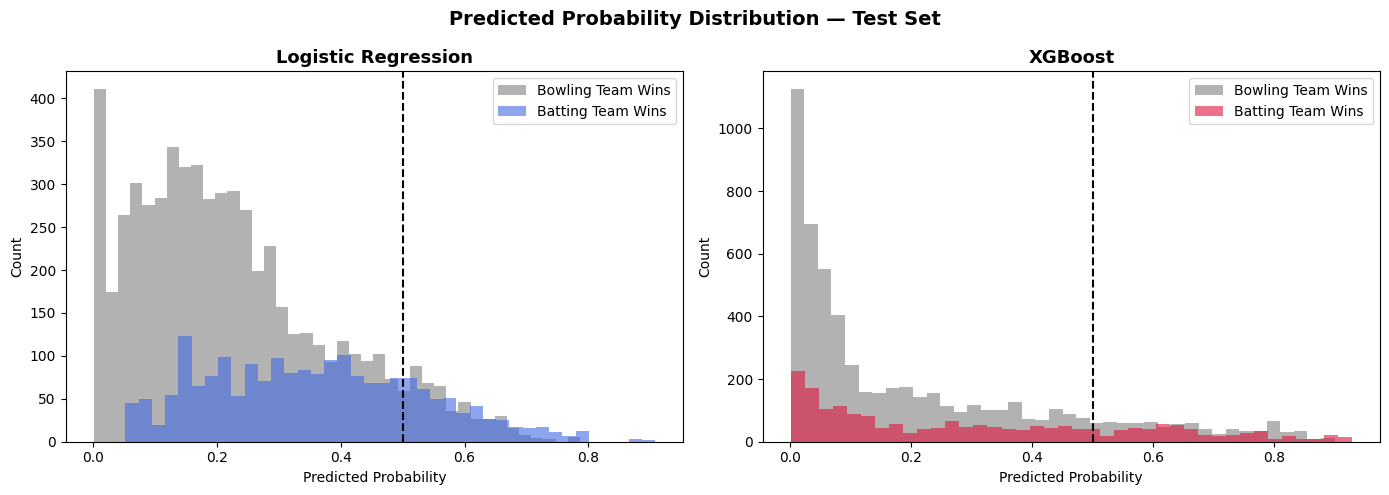

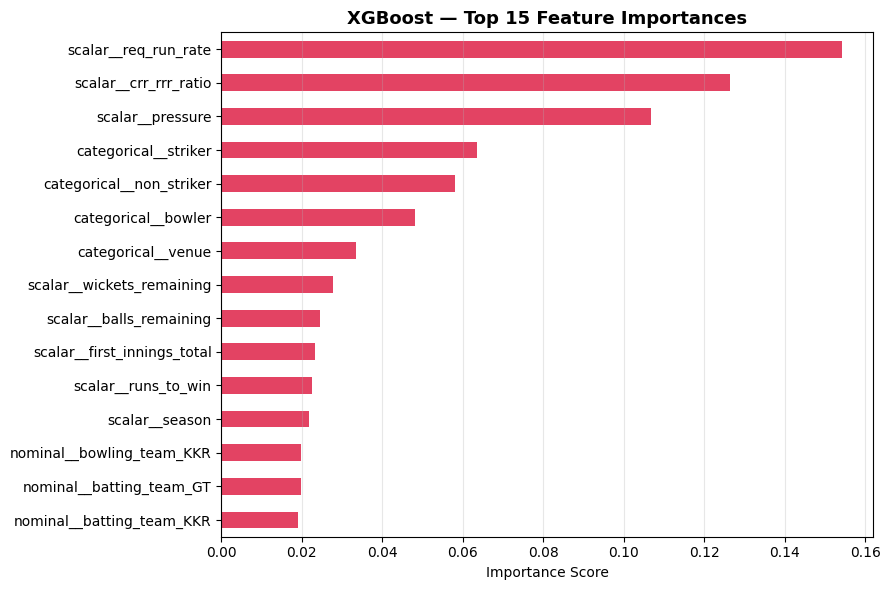


                     FINAL SUMMARY                     
Model                  Split       Acc     F1     AUC
-------------------------------------------------------
Logistic Regression    Train    0.7647 0.4289  0.8128
Logistic Regression    Test     0.7425 0.3092  0.7242
XGBoost                Train    0.8347 0.6599  0.9037
XGBoost                Test     0.7099 0.3108  0.6210
Ensemble (0.65/0.35)   Test     0.7294 0.3123  0.6675


In [428]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, log_loss, brier_score_loss
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Probabilities ──────────────────────────────────────────
# Logistic Regression
lr_train_prob  = pipe.predict_proba(x_train)[:, 1]
lr_test_prob   = pipe.predict_proba(x_test)[:, 1]

lr_train_pred  = pipe.predict(x_train)
lr_test_pred   = pipe.predict(x_test)

# XGBoost
xgb_train_prob = xgb_pipe.predict_proba(x_train)[:, 1]
xgb_test_prob  = xgb_pipe.predict_proba(x_test)[:, 1]

xgb_train_pred = xgb_pipe.predict(x_train)
xgb_test_pred  = xgb_pipe.predict(x_test)

# ── Metrics Function ───────────────────────────────────────
def full_metrics(name, y_true, y_pred, y_prob):
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1 Score  : {f1_score(y_true, y_pred):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"  Log Loss  : {log_loss(y_true, y_prob):.4f}")
    print(f"  Brier     : {brier_score_loss(y_true, y_prob):.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred,
                                 target_names=['Bowling Team Wins',
                                               'Batting Team Wins']))

# ── Print All Metrics ──────────────────────────────────────
print("\n" + "★"*45)
print("   LOGISTIC REGRESSION")
print("★"*45)
full_metrics("LR — Train", y_train, lr_train_pred, lr_train_prob)
full_metrics("LR — Test",  y_test,  lr_test_pred,  lr_test_prob)

print("\n\n" + "★"*45)
print("   XGBOOST")
print("★"*45)
full_metrics("XGB — Train", y_train, xgb_train_pred, xgb_train_prob)
full_metrics("XGB — Test",  y_test,  xgb_test_pred,  xgb_test_prob)

# ── Confusion Matrices ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices — Test Set', fontsize=15, fontweight='bold')

for ax, preds, title in zip(
    axes,
    [lr_test_pred, xgb_test_pred],
    ['Logistic Regression', 'XGBoost']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Bowl Wins', 'Bat Wins'],
                yticklabels=['Bowl Wins', 'Bat Wins'])
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# ── ROC Curves ────────────────────────────────────────────
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

for probs, name, color in [
    (lr_test_prob,  'Logistic Regression', 'royalblue'),
    (xgb_test_prob, 'XGBoost',             'crimson'),
    ((0.65*xgb_test_prob + 0.35*lr_test_prob), 'Ensemble', 'green')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, lw=2)

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Test Set', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Probability Distribution ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Predicted Probability Distribution — Test Set',
             fontsize=14, fontweight='bold')

for ax, probs, title, color in zip(
    axes,
    [lr_test_prob, xgb_test_prob],
    ['Logistic Regression', 'XGBoost'],
    ['royalblue', 'crimson']
):
    ax.hist(probs[y_test==0], bins=40, alpha=0.6,
            label='Bowling Team Wins', color='gray')
    ax.hist(probs[y_test==1], bins=40, alpha=0.6,
            label='Batting Team Wins', color=color)
    ax.axvline(0.5, color='black', linestyle='--', lw=1.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

# ── XGB Feature Importance ────────────────────────────────
xgb_model    = xgb_pipe.named_steps['xgbclassifier']
feature_names = xgb_pipe.named_steps['columntransformer']\
                         .get_feature_names_out()

importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
importance.plot(kind='barh', ax=ax, color='crimson', alpha=0.8)
ax.set_title('XGBoost — Top 15 Feature Importances',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Final Summary Table ────────────────────────────────────
print("\n" + "="*55)
print(f"{'FINAL SUMMARY':^55}")
print("="*55)
print(f"{'Model':<22} {'Split':<8} {'Acc':>6} {'F1':>6} {'AUC':>7}")
print("-"*55)

for name, yt, yp, yprob, split in [
    ('Logistic Regression', y_train, lr_train_pred, lr_train_prob, 'Train'),
    ('Logistic Regression', y_test,  lr_test_pred,  lr_test_prob, 'Test'),
    ('XGBoost',             y_train, xgb_train_pred,xgb_train_prob,'Train'),
    ('XGBoost',             y_test,  xgb_test_pred, xgb_test_prob,'Test'),
]:
    acc = accuracy_score(yt, yp)
    f1  = f1_score(yt, yp)
    auc = roc_auc_score(yt, yprob)
    print(f"{name:<22} {split:<8} {acc:>6.4f} {f1:>6.4f} {auc:>7.4f}")

# Ensemble row
ens_prob = 0.65*xgb_test_prob + 0.35*lr_test_prob
ens_pred = (ens_prob >= 0.5).astype(int)
print(f"{'Ensemble (0.65/0.35)':<22} {'Test':<8} "
      f"{accuracy_score(y_test,ens_pred):>6.4f} "
      f"{f1_score(y_test,ens_pred):>6.4f} "
      f"{roc_auc_score(y_test,ens_prob):>7.4f}")
print("="*55)

In [ ]:
np.unique(xgb_pipe.predict(x_test), return_counts=True)

In [ ]:

'''
row = pd.DataFrame([{
    'batting_team': 'GT',
    'bowling_team': 'RR',
    'runs_to_win': 105,
    'curr_run_rate': round(82 / (61/6), 2),   # 8.07
    'req_run_rate': round(105 / (59/6), 2),    # 10.68
    'crr_rrr_ratio': round((82 / (61/6)) / (105 / (59/6)), 2),  # 0.76,
    'balls_remaining': 59,
    'wickets_remaining':9 , #ONLY 1 OUT
    # 'batting_average': 28,
    # 'career_strike_rate': 140,
    # 'exp_bowler_eco': 7.2,
    # 'exp_bowler_avg': 26,
    'pressure':  round((105 / (59/6)) / (82 / (61/6)), 2),
    'first_innings_total':186,
    'match_phase':1,
    "venue":"narendra_modi_stadium"
}])


[0]
[[0.6575856 0.3424144]]
RR will win the match



row = pd.DataFrame([{
    'batting_team': 'GT',
    'bowling_team': 'RR',
    'runs_to_win': 78,
    'curr_run_rate': round(100 / (79/6), 2),      # 7.59
    'req_run_rate': round(78 / (41/6), 2),         # 11.41
    'crr_rrr_ratio': round((100/(79/6)) / (78/(41/6)), 2),  # 0.67
    'balls_remaining': 41,
    'wickets_remaining': 5,
    'pressure': round((78/(41/6)) / (100/(79/6)), 2),  # 1.50
    'first_innings_total': 177,
    'match_phase': 1,   # over 13 → middle (5-14)
    "venue": "narendra_modi_stadium"
}])

pred_lr = pipe.predict(row)
pred_lr_proba=pipe.predict_proba(row)
print(pred_lr)
print(pred_lr_proba)
if pred_lr == 1:
  print(row['batting_team'].values[0], "will win the match")
else:
  print(row['bowling_team'].values[0], 'will win the match')


[0]
[[0.83415954 0.16584046]]
RR will win the match

row = pd.DataFrame([{
    'batting_team': 'GT',
    'bowling_team': 'RR',
    'runs_to_win': 34,
    'curr_run_rate': round(144 / (99/6), 2),            # 8.73
    'req_run_rate': round(34 / (21/6), 2),               # 9.71
    'crr_rrr_ratio': round((144/(99/6)) / (34/(21/6)), 2),   # 0.90
    'balls_remaining': 21,
    'wickets_remaining': 7,
    'pressure': round((34/(21/6)) / (144/(99/6)), 2),    # 1.11
    'first_innings_total': 177,
    'match_phase': 2,   # over 16 → death
    "venue": "narendra_modi_stadium"
}])

pred_lr = pipe.predict(row)
pred_lr_proba=pipe.predict_proba(row)
print(pred_lr)
print(pred_lr_proba)
if pred_lr == 1:
  print(row['batting_team'].values[0], "will win the match")
else:
  print(row['bowling_team'].values[0], 'will win the match')


[0]
[[0.58845044 0.41154956]]
RR will win the match

'''